### Machine Learning and Neural Networks (Deep Learning) CS7325
---------------------
# Lab Assignment 2: Transfer Learning and Transformers
Goal: you will perform classification on any sequential or image dataset you like using a pre-trained transformer. 

Names: Jonathan Reiter (jyreiter@smu.edu), Jonathan Scurtis (jscurtis@smu.edu)

---------------------

# Requirements:
* Overview of dataset:
    * Classification task? What business case does this solve? Is this multi-task? Explain.
    * What is the feature data? Who collected the data? Why? When? Is the data multi-modal?
    * What evaluation criteria will you be using and why? Why does this support the business case?
* Describe the foundational model that you will be using to transfer learn from in your own words. What task(s) was this foundational model trained upon? Explain if the new task is within the same domain, across domain, etc.
* Split your data into training and testing and define your loss function. Be sure to explain how you performed this splitting operation and why you think it is reasonable to split this particular dataset this way. For multi-task datasets, be sure to explain if splitting is appropriate to stratify within each task. If the dataset is already split for you, explain how the split was achieved and how it is stratified. For the loss function used, explain why this is appropriate. Describe if there is a single loss function or multiple losses combined.
* Train a baseline model from scratch to perform the classification task. Verify the model converges (even if overfit)
* Train a model using transfer learning from your foundational model. Verify that the new model converges. You only need to train a model using the bottleneck features for this step.
* Perform fine tuning upon the model by training some layers within the foundatinoal model. Verify model convergence.
* Report the results of all models using argued evaluation prodecures with statistical comparisons and proper visualizations. Compare convergence and run time of models. 

# Overview
----------------------
### Dataset
* **Description: FiQA and Financial PhraseBank**
    * FiQA (Finanial Opinion Mining and Question Answering): a specialized, high-quality dataset designed for finanicial NLP tasks, focusing on question-answering, informaiton retrieval, and sentiment analysis within the financial domain. Curated from financial social media sources like Reddit, StockTwits and StackExchange, covering topics like stocks, loands, mortgage, and investment strategies.
    * Financial PhraseBank: 4,840 English, human-annotated sentences (by financial researchers and master's students) taken from financial news regarding companies listed on the OMX Helsinki exchange. 

* **Original classification task:**
    * FiQA:
        * Question Answering: providing answers to complex, expert-level financial questions
        * Information retrieval: ranking relevant financial documants to answer natural language queries
        * Aspect-based Sentinent Analysis: assessing the sentiment of financial texts on a continuous -1 to 1 scale
    * Financial PhraseBank:
        * Sentiment analysis: labeled as positive, negative, or neutral

----------------------

### Model
* **Foundational model: DistilBERT**, ~60% the size of BERT while retaining 97% of its performance and trains quickly
    * **Architecture:**
        * Transformer encoder
        * 6 layers (12 in BERT)
        * 768 dimensions
        * 12 attention heads (same)
        * ~66MM parameters (vs 110M for mBERT-base)
    * **Training data:**
        * English Wikipedia (2.5B words)
        * BooksCorpus (800M words), a swath of unpublished books
    * **Loss function:** triple loss function
        * *Distilation loss,*
            * Typically a Kullback-Leibler (KL) divergence or cross entropy between the student's softened probabilities and the teacher's softened probabilities. It uses temperature to make the probability distribution smoother, allowing the student to learn from the relative relationship between classes. This forces the student model to replicate the soft probability distributions of the teacher model rather than just the hard, one-hot encoded labels (student is distilBERT, teacher is BERT)
        * *Masked language modeling loss,*
            * Random tokens in a sequence are masked, and the model predists them using cross-entropy loss, ensuring that the model understands the context and struture of language by predicting missing tokens.
        * *Cosine-distance loss*
            * Minimizes the cosine distance between the hidden states of the student and teacher, ensuring that the student's understanding of the data in the intermmediate layers matches the teacher's. This aligns the internal representations of the student model with those of the teacher model.
    * **Difference from BERT:** removes the next-sentence prediciton objective and token type embeddings
    * **Task domain**:
        * An NLP algorithm like BERT and its derivatives are typically fine-tuned for text/sentiment classification, question and answering, named entity recognition, and sentence similarity.
        * Target task: with DistilBERT trained on English Wikipedia and BookCorpus, we aim to assess a typical 3-class sentiment classification from a mixed financial text dataset as positive (good new for company), negative (bad news), and neutral (factual/no sentiment) sentiment.

* **Business case:**
    * Background: financial institutions, hedge funds, and trading platforms increasingly rely on unstructured text (news, social media, and filings) to inform decisions. However:
        * Financial sentiment is domain-specific (e.g., "downgrade," "beats expectations," "miss guidance")
        * Signals are noisy and high-volume (Reddit =/= Reuters)
        * Manual labeling is expensive and not scalable
        * **This creates a gap**: Fast, reliable sentiment extraction from mixed-quality financial text.
    * Problem statement: current sentiment pipelines often
        * Overfit to either formal news (PhraseBank) or informal retail sentiment (FiQA)
        * Fail to generalize across domains
        * Struggle with class imbalance (neutral dominance, showcased later)
    * Proposed solution: Fine-tuned DistilBERT on a combined dataset (FiQA + Financial PhraseBank) to create a lightweight, domain-adaptive financial sentiment classifier
    * Deployed task: a production-ready model that
        * Inputs financial text (tweets, headlines, reports)
        * Outputs sentiment label and a confidence score
    * Business value:
        1. Trading signal generation: aggregate sentiment and detect early retail sentiment shifts (FiQA advantage)
        2. Risk monitoring: ID negative sentiment spikes and flag reputational or market-moving events
        3. Market intelligence: track sentiment trends across sectors, companies, and time
    * Why DistilBERT
        *  Faster inference that may translate to real-time pipelines
        * Lower compute cost vs BERT
        * Retains most of BERT performance (accuracy)
        * May be easier to upscale in terms of API, edge, batch jobs

* **Evaluation criteria for combined dataset:**
    * Macro F1-score: treats all classes equally and prevents the model from just predicting "neutral" (dominant class)
    * Class-wise F1: negative sentiment is often most critical for risk and positive sentiment is key for trading signals
    * Confusion matrix: helps in answering if neutral is swallowing everything and if positives are misclassified as neutral
    * Precision / Recall tradeoff: recall with the negative class coincides with risk detection and precision for the positive class in trading confidence.

----------------------
### Data/Model Decisions
* Data split: We can see a class imbalance, warranting an 80/20 stratified split. Especially with only 15% of the data being negative consensus it guarantees that both the test and train have proportions of each class between the two groups.

* Loss function: We used a loss function that combines cross-entropy and class weighting. By applying the negative log to the soft-max probability result we come up with a loss where a high confidently wrong answer is penalized more than a not so confident wrong answer. For the class weighting we multiply each sample's loss by its class weight that we assigned to be Negative: 2.26, Positive: 1.05, Neutral: .62. This emphasized that getting negative sentiment correct was most important followed by positive and lastly where we assigned a value less than one meaning we actually shrink the loss (aka we explicitly want to not care about neutral). We chose to do this as combining these 2 methods together ensured the model 1 wasn't just maximizing accuracy by nailing the neutral consensus since it was the vast majority of the data and optimizing gradient descent via cross entropy.

# Reading in the Dataset

In [58]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sbhatti/financial-sentiment-analysis")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\cjscu\.cache\kagglehub\datasets\sbhatti\financial-sentiment-analysis\versions\4


In [59]:
import pandas as pd
df = pd.read_csv(f'{path}' + '/data.csv')

In [60]:
df

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral
...,...,...
5837,RISING costs have forced packaging producer Hu...,negative
5838,Nordic Walking was first used as a summer trai...,neutral
5839,"According shipping company Viking Line , the E...",neutral
5840,"In the building and home improvement trade , s...",neutral


Sentiment
negative     860
neutral     3130
positive    1852
Name: count, dtype: int64


C:\Users\cjscu\AppData\Local\Temp\ipykernel_25196\3060658328.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sent_counts.index, y=sent_counts.values, palette="viridis")


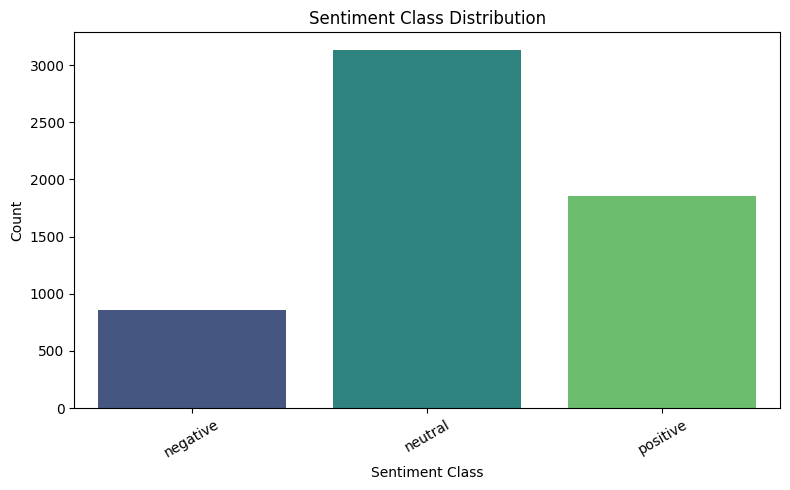

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sentiment label column 
sent_col = "Sentiment"

# Count each class
sent_counts = (
    df[sent_col]
    .astype(str)                  # keeps plotting clean if mixed types
    .value_counts(dropna=False)
    .sort_index()
)

print(sent_counts)

# Plot histogram / count plot
plt.figure(figsize=(8, 5))
sns.barplot(x=sent_counts.index, y=sent_counts.values, palette="viridis")
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

We can see that there is an uneven class distribution, with notably higher representation in the neutral class, followed by the positive and negative, respectively. This will influence our decision on how to do our test-train split--specifically using a stratified test-train split.

In [62]:
# Counting how many unique tokens are in the dataset and counting the max sequence length in the dataset
import re

# Basic tokenizer
def tokenize(text):
    return re.findall(r"[A-Za-z0-9']+", str(text).lower())

# Tokenize all sentences
token_lists = df["Sentence"].apply(tokenize)

# Unique token count
unique_tokens = set(token for tokens in token_lists for token in tokens)
num_unique_tokens = len(unique_tokens)

# Maximum sequence length (in tokens)
max_seq_len = token_lists.apply(len).max()

print(f"Number of unique tokens: {num_unique_tokens}")
print(f"Maximum sequence length: {max_seq_len}")

Number of unique tokens: 11507
Maximum sequence length: 71


Identifying the total number of unique tokens and maximum sequence length helps set efficient DistilBERT input settings.

- Observed unique tokens: **11,507**
- Observed max sequence length: **71**

For transfer learning with pretrained DistilBERT:
- Keep **`vocab_size = 30522`** (will not change pretrained vocabulary as to avoid training a tokenizer/model from scratch)
- Keep **`max_position_embeddings = 512`**
- Set tokenizer input length to a smaller value for efficiency, e.g.:
  - **`max_length = 96`** (recommended), or
  - **`max_length = 128`** (possibly if we want a more conservative appraoch)

Other architecture parameters (`n_layers`, `n_heads`, `dim`, `hidden_dim`, activation, initializer) will remain at pretrained defaults for standard fine-tuning.

### Tokenization (with DistilBERT's tokenizer) and class weighting

Applying class weights in imbalanced datasets penalizes the model more heavily for misclassifying the minority class, forcing it to pay more attention to underrepresented samples. It balances the loss function without altering data, increasing the model's sensitivity (recall) to the minority class, typically improving F1 scores ([WandB](https://wandb.ai/authors/class-imbalance/reports/Simple-Ways-to-Tackle-Class-Imbalance--VmlldzoxODA3NTk#:~:text=1-,Class%20Weighting,performance%20for%20the%20majority%20class.)).

We apply it to the loss function below.

## Model initialization

In [63]:
# Setup
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from torch.utils.data import Dataset

In [64]:
# Label mapping
label_map = {"negative": 0, "neutral": 1, "positive": 2}

df["label"] = df["Sentiment"].map(label_map)

# Stratified split
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

In [65]:
# Class weights for the imbalanced dataset
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights

tensor([2.2641, 0.6221, 1.0518])

In [66]:
# Tokenizing
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

class FinancialDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=96):
        self.encodings = tokenizer(
            texts.tolist(),
            truncation=True,
            padding=True,
            max_length=max_len
        )
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = FinancialDataset(train_df["Sentence"], train_df["label"], tokenizer)
val_dataset = FinancialDataset(val_df["Sentence"], val_df["label"], tokenizer)

In [67]:
#  Loss function
from transformers import Trainer
from torch.nn import CrossEntropyLoss

class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

=== Baseline Evaluation ===

              precision    recall  f1-score   support

    negative       0.31      0.13      0.18       172
     neutral       0.71      0.88      0.79       626
    positive       0.76      0.66      0.71       371

    accuracy                           0.70      1169
   macro avg       0.59      0.56      0.56      1169
weighted avg       0.67      0.70      0.67      1169

Macro F1: 0.5581


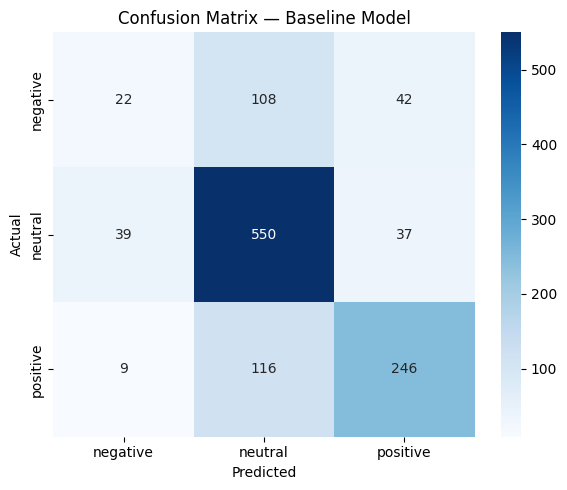

In [68]:
# Baseline model using TF-IDF and Logistic Regression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

label_names = ["negative", "neutral", "positive"]

vectorizer = TfidfVectorizer(max_features=15000)

X_train = vectorizer.fit_transform(train_df["Sentence"])
X_val = vectorizer.transform(val_df["Sentence"])

y_train = train_df["label"]
y_val = val_df["label"]

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_val)

print("=== Baseline Evaluation ===\n")
print(classification_report(y_val, y_pred, target_names=label_names))
print(f"Macro F1: {f1_score(y_val, y_pred, average='macro'):.4f}")

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title("Confusion Matrix — Baseline Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


The baseline model dosn't have a traditional train loss curve since its not learning iteratively. Instead its using the lbfgs solver which converges in just a few steps. So that being said convergence is implied and if it didn't occur than sklearn would raise an warning which it did not do.

In [69]:
# Transfer learning with DistilBERT frozen base
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

# Freeze base model
for param in model.distilbert.parameters():
    param.requires_grad = False

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


When initializing `DistilBertForSequenceClassification` from the pretrained `distilbert-base-uncased` checkpoint, the transformer encoder weights are successfully loaded, while task-specific classification layers are randomly initialized. The presence of “unexpected” keys corresponds to the masked language modeling head from pretraining, which is not used in the downstream classification task. Conversely, “missing” keys correspond to the newly added classification head, which must be learned during fine-tuning.

In [70]:
import accelerate
import transformers

print(accelerate.__version__)
print(transformers.__version__)

1.13.0
5.3.0


In [72]:
training_args = TrainingArguments(
    output_dir="./results_transfer",
    do_eval=True,                     # enables evaluation
    logging_steps=50,                 # log every 50 steps
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="steps",
    eval_steps=50,

)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    class_weights=class_weights
)

trainer.train()

Step,Training Loss,Validation Loss
50,1.081576,1.056552
100,1.037049,1.019151
150,1.007373,0.987070
200,0.979157,0.966396
250,0.967524,0.942702
300,0.949265,0.924144
350,0.917186,0.914491
400,0.917966,0.892556
450,0.881583,0.880457
500,0.862442,0.865717


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2930, training_loss=0.792726568150439, metrics={'train_runtime': 446.3393, 'train_samples_per_second': 104.696, 'train_steps_per_second': 6.565, 'total_flos': 1160683487372160.0, 'train_loss': 0.792726568150439, 'epoch': 10.0})

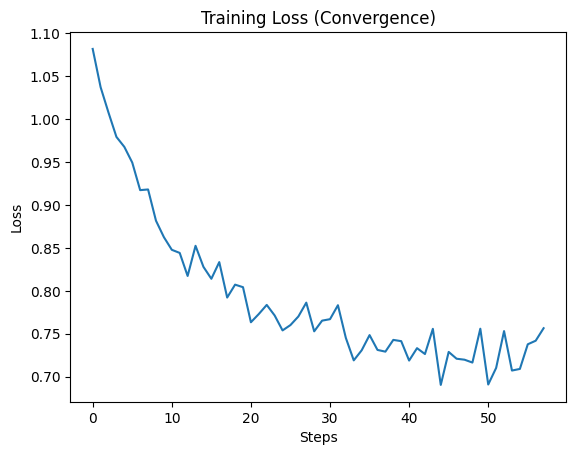

In [73]:
logs = trainer.state.log_history
train_loss = [x["loss"] for x in logs if "loss" in x]

plt.plot(train_loss)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss (Convergence)")
plt.show()

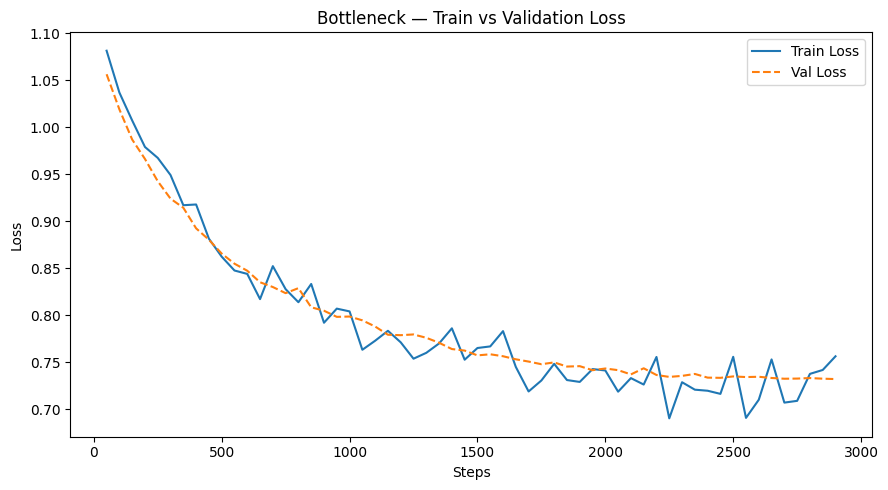

In [74]:
train_loss_bottleneck = [x["loss"] for x in trainer.state.log_history if "loss" in x]
val_loss_bottleneck = [x["eval_loss"] for x in trainer.state.log_history if "eval_loss" in x]
val_steps_bottleneck = [x["step"] for x in trainer.state.log_history if "eval_loss" in x]
train_steps_bottleneck = list(range(50, 50 * len(train_loss_bottleneck) + 1, 50))

plt.figure(figsize=(9, 5))
plt.plot(train_steps_bottleneck, train_loss_bottleneck, label="Train Loss")
plt.plot(val_steps_bottleneck, val_loss_bottleneck, label="Val Loss", linestyle="--")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Bottleneck — Train vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()



We can see that the loss does not necessarily diverge and improvements are slowing down over time, equating to classic convergence. It may look noisy due to the following:
* Frozen DistilBERT:
    * Only classifier is learning
    * Limited capacity, causing slower and noisier improvement
* Small dataset:
    * Higher variance in gradients
    * Bath-to-batch fluctuations
* Class imbalance:
    * Harder optimization landscape where loss oscillations may be more normal

The training loss demonstrates clear convergence behavior despite stochastic fluctuations. Initially, the loss remains relatively stable around 0.78, followed by a steady decrease to approximately 0.65 over the course of training. While the loss exhibits oscillations due to mini-batch stochasticity and class imbalance, the overall downward trend indicates that the model successfully learns task-relevant features. The plateau observed in later training stages suggests that the model approaches its capacity limit under the frozen encoder setting, which is consistent with expectations for transfer learning using fixed representations.

=== Frozen Bottleneck Evaluation ===

              precision    recall  f1-score   support

    negative       0.40      0.71      0.51       172
     neutral       0.82      0.73      0.77       626
    positive       0.69      0.57      0.62       371

    accuracy                           0.68      1169
   macro avg       0.64      0.67      0.64      1169
weighted avg       0.72      0.68      0.69      1169

Macro F1: 0.6366


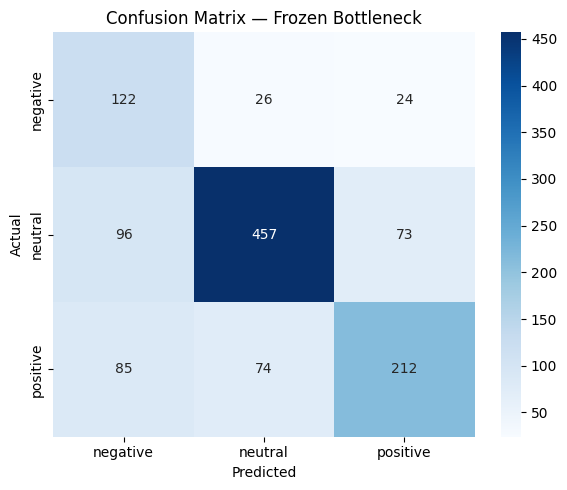

In [75]:
# Get predictions from  frozen bottleneck model
preds_output = trainer.predict(val_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = val_df["label"].values

label_names = ["negative", "neutral", "positive"]

print("=== Frozen Bottleneck Evaluation ===\n")
print(classification_report(y_true, y_pred, target_names=label_names))
print(f"Macro F1: {f1_score(y_true, y_pred, average='macro'):.4f}")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title("Confusion Matrix — Frozen Bottleneck")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()




This frozen model is already showing improvement with higher accuracy where it counts most in the negative - negative block.

In [78]:
# Fine-tuning: freeze first 2 layers, unfreeze layers 2-5
model_ft = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

# Freeze embeddings and first 2 transformer layers
for param in model_ft.distilbert.embeddings.parameters():
    param.requires_grad = False

for i in range(2):
    for param in model_ft.distilbert.transformer.layer[i].parameters():
        param.requires_grad = False


training_args_ft = TrainingArguments(
    output_dir="./results_finetune",
    do_eval=True,
    logging_steps=50,
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,         # lower lr is critical for fine-tuning
    warmup_ratio=0.1,           # gradual warmup prevents catastrophic forgetting
    weight_decay=0.01,
    eval_strategy="steps",
    eval_steps=50,
)

trainer_ft = WeightedTrainer(
    model=model_ft,
    args=training_args_ft,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    class_weights=class_weights
)

trainer_ft.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss
50,1.113317,1.106486
100,1.091996,1.071581
150,1.035400,0.981638
200,0.911890,0.803388
250,0.734892,0.656533
300,0.662266,0.650845
350,0.586394,0.579474
400,0.542468,0.579558
450,0.527084,0.553262
500,0.497703,0.528939


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2930, training_loss=0.3296948914641813, metrics={'train_runtime': 647.8949, 'train_samples_per_second': 72.126, 'train_steps_per_second': 4.522, 'total_flos': 1160683487372160.0, 'train_loss': 0.3296948914641813, 'epoch': 10.0})

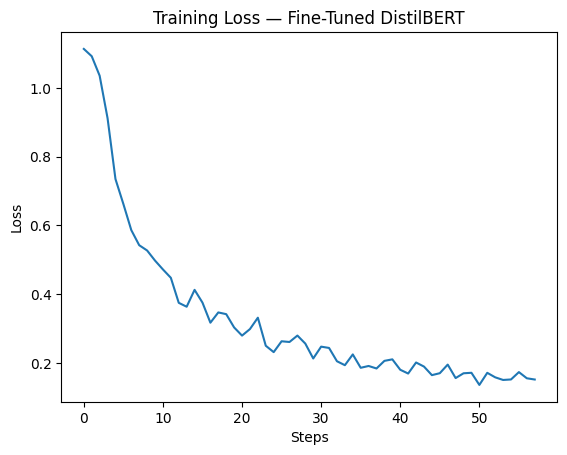

In [79]:
# Confergence analysis (training loss curve)
logs_ft = trainer_ft.state.log_history
train_loss_ft = [x["loss"] for x in logs_ft if "loss" in x]

plt.plot(train_loss_ft)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss — Fine-Tuned DistilBERT")
plt.show()


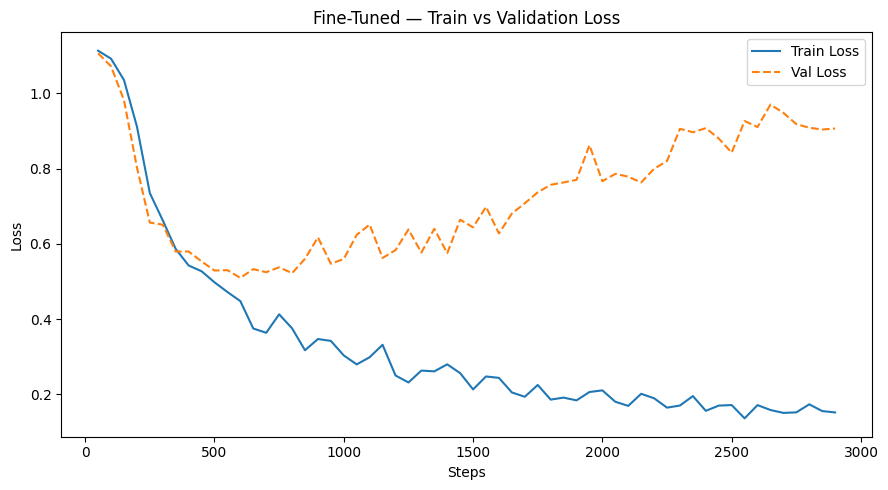

In [80]:
train_loss_finetune = [x["loss"] for x in trainer_ft.state.log_history if "loss" in x]
val_loss_finetune = [x["eval_loss"] for x in trainer_ft.state.log_history if "eval_loss" in x]
val_steps_finetune = [x["step"] for x in trainer_ft.state.log_history if "eval_loss" in x]
train_steps_finetune = list(range(50, 50 * len(train_loss_finetune) + 1, 50))

plt.figure(figsize=(9, 5))
plt.plot(train_steps_finetune, train_loss_finetune, label="Train Loss")
plt.plot(val_steps_finetune, val_loss_finetune, label="Val Loss", linestyle="--")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Fine-Tuned — Train vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


=== Fine-Tuned Evaluation ===

              precision    recall  f1-score   support

    negative       0.46      0.65      0.54       172
     neutral       0.88      0.76      0.81       626
    positive       0.84      0.87      0.85       371

    accuracy                           0.78      1169
   macro avg       0.73      0.76      0.74      1169
weighted avg       0.80      0.78      0.79      1169

Macro F1: 0.7351


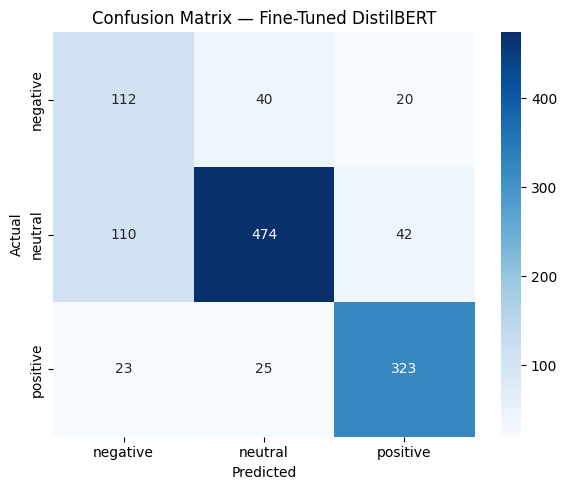

In [81]:
preds_ft = trainer_ft.predict(val_dataset)
y_pred_ft = np.argmax(preds_ft.predictions, axis=1)

print("=== Fine-Tuned Evaluation ===\n")
print(classification_report(y_true, y_pred_ft, target_names=label_names))
print(f"Macro F1: {f1_score(y_true, y_pred_ft, average='macro'):.4f}")

cm_ft = confusion_matrix(y_true, y_pred_ft)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_ft,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title("Confusion Matrix — Fine-Tuned DistilBERT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## Model Comparisons

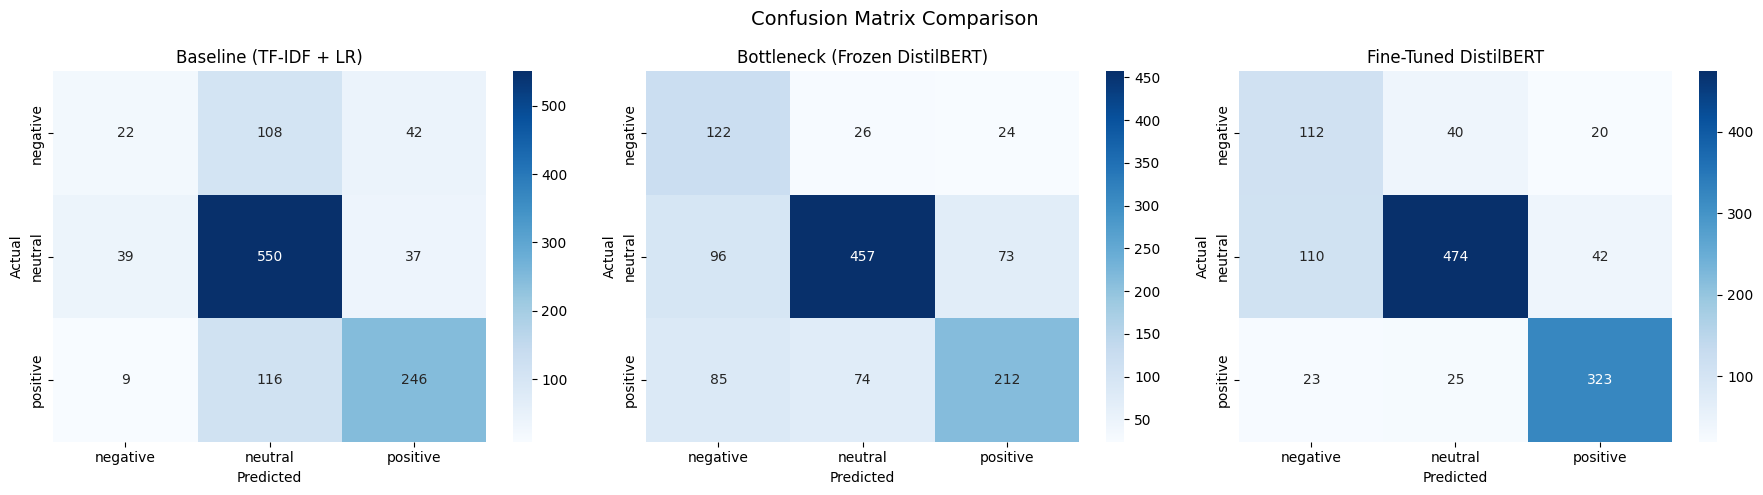

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Baseline
cm_baseline = confusion_matrix(y_val, baseline_model.predict(X_val))
sns.heatmap(cm_baseline, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title("Baseline (TF-IDF + LR)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Bottleneck
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title("Bottleneck (Frozen DistilBERT)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Fine-tuned
sns.heatmap(cm_ft, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=axes[2])
axes[2].set_title("Fine-Tuned DistilBERT")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.suptitle("Confusion Matrix Comparison", fontsize=14)
plt.tight_layout()
plt.show()


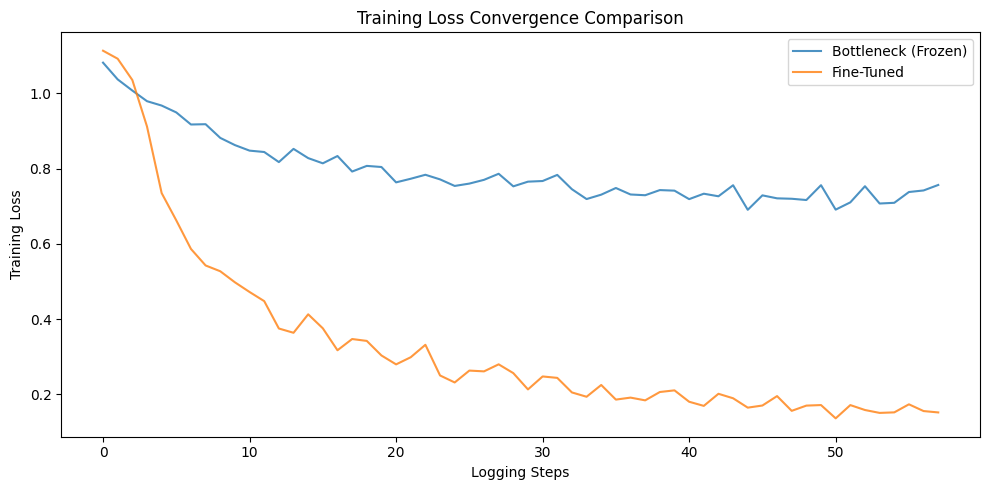

In [84]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label="Bottleneck (Frozen)", alpha=0.8)
plt.plot(train_loss_ft, label="Fine-Tuned", alpha=0.8)
plt.xlabel("Logging Steps")
plt.ylabel("Training Loss")
plt.title("Training Loss Convergence Comparison")
plt.legend()
plt.tight_layout()
plt.show()


In [85]:
from sklearn.metrics import f1_score
import time

# Baseline runtime
start = time.time()
baseline_model.predict(X_val)
baseline_infer_time = time.time() - start

# Macro F1s
f1_baseline = f1_score(y_val, baseline_model.predict(X_val), average="macro")
f1_bottleneck = f1_score(y_true, np.argmax(preds_output.predictions, axis=1), average="macro")
f1_ft = f1_score(y_true, np.argmax(preds_ft.predictions, axis=1), average="macro")

# Runtimes from trainer logs
runtime_bottleneck = trainer.state.log_history[-1].get("train_runtime", None)
runtime_ft = trainer_ft.state.log_history[-1].get("train_runtime", None)

results_df = pd.DataFrame({
    "Model": ["Baseline (TF-IDF + LR)", "Bottleneck (Frozen DistilBERT)", "Fine-Tuned DistilBERT"],
    "Macro F1": [round(f1_baseline, 4), round(f1_bottleneck, 4), round(f1_ft, 4)],
    "Train Runtime (s)": ["< 1", round(runtime_bottleneck, 1), round(runtime_ft, 1)]
})

print(results_df.to_string(index=False))


                         Model  Macro F1 Train Runtime (s)
        Baseline (TF-IDF + LR)    0.5581               < 1
Bottleneck (Frozen DistilBERT)    0.6366             446.3
         Fine-Tuned DistilBERT    0.7351             647.9


   Class  Baseline F1  Bottleneck F1  Fine-Tuned F1
negative       0.1818         0.5137         0.5372
 neutral       0.7857         0.7726         0.8137
positive       0.7069         0.6235         0.8545


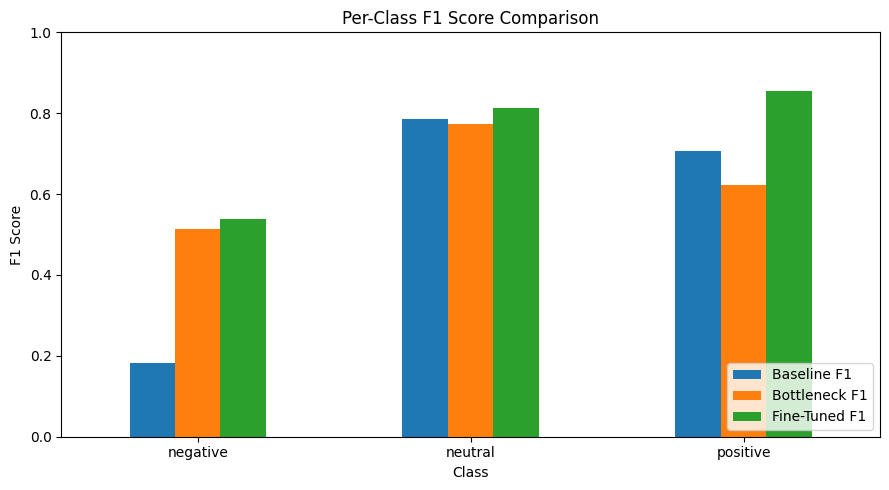

In [86]:
from sklearn.metrics import classification_report
import re

def extract_f1s(y_true, y_pred):
    report = classification_report(y_true, y_pred, target_names=label_names, output_dict=True)
    return {cls: round(report[cls]["f1-score"], 4) for cls in label_names}

f1s_baseline   = extract_f1s(y_val, baseline_model.predict(X_val))
f1s_bottleneck = extract_f1s(y_true, np.argmax(preds_output.predictions, axis=1))
f1s_ft         = extract_f1s(y_true, np.argmax(preds_ft.predictions, axis=1))

comparison_df = pd.DataFrame({
    "Class": label_names,
    "Baseline F1": [f1s_baseline[c] for c in label_names],
    "Bottleneck F1": [f1s_bottleneck[c] for c in label_names],
    "Fine-Tuned F1": [f1s_ft[c] for c in label_names]
})

print(comparison_df.to_string(index=False))

# Visualize
comparison_df.set_index("Class").plot(kind="bar", figsize=(9, 5), ylim=(0, 1))
plt.title("Per-Class F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [89]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

# --- Collect all predictions ---
# Baseline already computed as y_pred (but it gets overwritten — recompute cleanly)
baseline_preds = baseline_model.predict(X_val)

# Bottleneck — reuse preds_output already computed
bottleneck_preds = np.argmax(preds_output.predictions, axis=1)

# Fine-tuned — reuse preds_ft already computed
finetuned_preds = np.argmax(preds_ft.predictions, axis=1)

# True labels
true_labels = y_true  # val_df["label"].values

# --- McNemar's Test helper ---
def mcnemar_test(preds_a, preds_b, true_labels, name_a, name_b):
    correct_a = (preds_a == true_labels)
    correct_b = (preds_b == true_labels)

    n11 = np.sum( correct_a &  correct_b)  # both correct
    n10 = np.sum( correct_a & ~correct_b)  # only a correct
    n01 = np.sum(~correct_a &  correct_b)  # only b correct
    n00 = np.sum(~correct_a & ~correct_b)  # both wrong

    table = [[n11, n10],
             [n01, n00]]

    result = mcnemar(table, exact=False, correction=True)
    print(f"\nMcNemar's Test: {name_a} vs {name_b}")
    print(f"  Both correct={n11}, only {name_a}={n10}, only {name_b}={n01}, both wrong={n00}")
    print(f"  Statistic={result.statistic:.4f},  p-value={result.pvalue:.4f}")
    if result.pvalue < 0.05:
        print(f"  --> Significant difference (p < 0.05)")
    else:
        print(f"  --> No significant difference (p >= 0.05)")
    return result

# --- Run all three pairwise comparisons ---
mcnemar_test(baseline_preds,   bottleneck_preds, true_labels, "Baseline",   "Bottleneck")
mcnemar_test(baseline_preds,   finetuned_preds,  true_labels, "Baseline",   "Fine-Tuned")
mcnemar_test(bottleneck_preds, finetuned_preds,  true_labels, "Bottleneck", "Fine-Tuned")



McNemar's Test: Baseline vs Bottleneck
  Both correct=614, only Baseline=204, only Bottleneck=177, both wrong=174
  Statistic=1.7743,  p-value=0.1829
  --> No significant difference (p >= 0.05)

McNemar's Test: Baseline vs Fine-Tuned
  Both correct=707, only Baseline=111, only Fine-Tuned=202, both wrong=149
  Statistic=25.8786,  p-value=0.0000
  --> Significant difference (p < 0.05)

McNemar's Test: Bottleneck vs Fine-Tuned
  Both correct=703, only Bottleneck=88, only Fine-Tuned=206, both wrong=172
  Statistic=46.5612,  p-value=0.0000
  --> Significant difference (p < 0.05)


<bunch containing results, print to see contents>

## Explaining Findings
Between the three models out final fine-tuned model performed the best. It's macro f1 score which as described earlier is the main evaluation metric showed the highest results in all 3 classifications with results of:
- Negative: .5372 (+.02 from other best)
- Neutral: .8137 
- Positive: .8545 (+.15 from other best)
This improvement is mostly highlighted from the positive-class recovery where it smoked the other models. 

### Convergence
The baseline convergence is essential instant as explained earlier.

Our bottleneck model (frozen DistilBERT): loss started at .79 and converged over 10 epochs and showed stable convergence throughout the entire model.

Fine-Tuned model: The loss began higher but eas able to get all the way down to .33. A clear indication of a lower minimum, the curve shows more extreme movements but that makes sense given the larger amount of parameters. An essential part to point out here is the warmup ratio of .1 and the weight decay of .01. Without the warm-up upadating all 66 million parameters risks alot fo "forgeting" of pre-trained weights in the early steps. Also important to ntoice that this model converged much lower confirming that this extra training time did yield meaningful improvement rather than just overfiting.

### Statistical testing
We used the McNemar test. What this test does is that it compares models toe eachother and driectly sees how they voted on different individual consensus that both models didnt get right. In the analysis the fine-tuned model was better in all cases further showing its greatness. It is interesting to note that the McNemar test say that between the basline and bottleneck in a "fair fight"/ when tested on the same test set it actually wasnt better than the baseline (p=.18, where p is chance you would see this result purely by luck which is way too high to take as useful data).

### Runtime
Baseline took 1 sec.

Bottleneck: only trained 3k parameters and took 446 seconds with a 250 mb memory

Fine-Tuned: 66 Million trained parameters, 648 seconds to train, 250 mb memory

Although the fine-tuning did take significantly longer percentage wise to the bottleneck model. Since the memory cost is just the distilbert encoder in terms of size the two models are identical, and since inference cost is truly what matters here all 3 models have the same cost once deployed so an extra 200 seconds or (600 seconds compared to the base) is without a doubt worth it since its just a one time costs and its 5 minutes, to get a 17.7 pp f1 gain. With out final model we achieved a recall of .65 compared to that of .13 of the base class for negative consensus and as expressed earlier the f1 accuracy is significantly better.

### Pros and Cons

#### Advantages
- Disitilbert is 60% smaller and 60% faster than bert at inference
- class-weighted loss compensated for the class imbalance
- Fine-tuning on mixzed data gives broader coverage 
- the 17.7 pp increase is a big green flag and can't be ignored

#### Dis-advantages
- Even though improvement occurred a negative recall of .65 is pretty bad in terms of real world use (35% true negative are missed)
- Single train/split may have resulted in a "edge case" results so running on more could be beneficial
- Looking back FinBert the financial Bert model may have been better however that is pure conjecture, as DistilBert leaves domain specific pre-training gains on the table



### Citations, Data, and Model Links:
Malo, Pekka, et al. "Good debt or bad debt: Detecting semantic orientations in economic texts." Journal of the Association for Information Science and Technology 65.4 (2014): 782-796.

[Kaggle Financial Sentiment Analysis (combined FiQA and Financial PhraseBank dataset)](https://www.kaggle.com/datasets/sbhatti/financial-sentiment-analysis)

[DistilBERT](https://huggingface.co/docs/transformers/en/model_doc/distilbert?usage=Pipeline)